# Applied Activity: From Lyrics to Vocabulary Construction
## Lexical Analysis of *Someone Like You* by Adele

**Course:** Fundamentos de AI (con NN y Transformers)  
**Activity:** 10 – Applied Activity  
**Objective:** Construct a reproducible lexical analysis pipeline that moves from raw text to tokenization, vocabulary construction, and normalization, illustrating key NLP preprocessing concepts.

---

> **Reproducibility Note:** All library versions are reported at the end of this notebook. No random seeds are required since all operations are fully deterministic. All cells must be run sequentially from top to bottom.

## 0. Environment Setup

We install and import all required libraries upfront to guarantee reproducibility.

| Library | Role |
|---------|------|
| `nltk` | Tokenization, POS tagging, stemming, lemmatization, stopwords, n-grams |
| `pandas` | Structured table display |
| `matplotlib` | All bar charts and visualizations |
| `wordcloud` | Word cloud visualizations |
| `re` | Rule-based regex tokenization |
| `collections.Counter` | Token frequency counting |

In [1]:
# ── Install libraries ─────────────────────────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["nltk", "pandas", "matplotlib", "wordcloud"]:
    install(pkg)

print("All packages installed successfully.")

All packages installed successfully.


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import nltk
from collections import Counter
from wordcloud import WordCloud
from nltk.util import ngrams

# ── Download NLTK corpora ─────────────────────────────────────────────────────
for resource in [
    "punkt", "punkt_tab", "stopwords",
    "wordnet", "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng"
]:
    nltk.download(resource, quiet=True)

# ── Global plot style ─────────────────────────────────────────────────────────
# We set a consistent style for all plots in this notebook.
# 'seaborn-v0_8-whitegrid' provides a clean background with subtle gridlines,
# making bar charts easier to read without visual clutter.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print("Imports and NLTK corpora ready.")

Imports and NLTK corpora ready.


---
## Section 1 — Text Description

### Song choice and rationale

The selected song is **"Someone Like You"** by **Adele** (2011), from the album *21*.

**Why this song?**
1. **Emotionally dense vocabulary:** Contains emotion, action, time, and negation words — ideal for a meaningful lexicon with varied conceptual categories.
2. **Morphological variety:** Words like *unsolicited*, *settled*, *married*, and *couldn't* allow rich morpheme, stemming, and lemmatization analyses.
3. **Clean syntactic structure:** Complete sentences benefit sentence tokenization; contractions illustrate tokenizer challenges.
4. **N-gram richness:** Recurring phrase patterns make unigram, bigram, and trigram analysis meaningful.

In [3]:
# ── Define the song fragment ──────────────────────────────────────────────────
# Stored as a single multi-line string — the single source of truth for all
# subsequent sections. Every analysis derives its input from this variable.

text = """I heard that you're settled down
That you found a girl and you're married now
I heard that your dreams came true
Guess she gave you things I couldn't give to you
Old friend, why are you so shy?
Ain't like you to hold back or hide away from the light
I hate to turn up out of the blue unsolicited
But I couldn't stay away, I couldn't fight it"""

print("Song fragment loaded:")
print("-" * 55)
print(text)
print("-" * 55)

Song fragment loaded:
-------------------------------------------------------
I heard that you're settled down
That you found a girl and you're married now
I heard that your dreams came true
Guess she gave you things I couldn't give to you
Old friend, why are you so shy?
Ain't like you to hold back or hide away from the light
I hate to turn up out of the blue unsolicited
But I couldn't stay away, I couldn't fight it
-------------------------------------------------------


---
## Section 2 — Lexicons

A **lexicon** is the set of words used in a language or domain. In NLP it defines the vocabulary a model can recognize and process. It is distinct from *vocabulary* (unique tokens in a corpus) and from individual *words* (single meaning units).

Building a lexicon is a **foundational step before tokenization and modeling**: by categorizing the most meaningful words we create a conceptual map that informs downstream preprocessing decisions.

In [4]:
# ── Build the lexicon ─────────────────────────────────────────────────────────
# Each entry has three fields as required by the task:
#   lexical_item : word or expression (base form)
#   category     : conceptual category
#   description  : short interpretation of the word's role in the text

lexicon_entries = [
    {"Lexical Item": "settled",      "Category": "state",      "Description": "Being in a stable, permanent situation (settled down)"},
    {"Lexical Item": "married",      "Category": "state",      "Description": "The subject's new relational status, triggering the narrator's reflection"},
    {"Lexical Item": "dreams",       "Category": "aspiration", "Description": "Goals or desires the subject once pursued; now fulfilled"},
    {"Lexical Item": "true",         "Category": "evaluation", "Description": "Confirmation that dreams were realized; implies contrast with narrator"},
    {"Lexical Item": "gave",         "Category": "action",     "Description": "What the new partner provided that the narrator could not"},
    {"Lexical Item": "couldn't",     "Category": "negation",   "Description": "Contraction expressing inability; central to the narrator's inadequacy"},
    {"Lexical Item": "friend",       "Category": "relation",   "Description": "Term of address indicating a past close relationship now reframed"},
    {"Lexical Item": "shy",          "Category": "emotion",    "Description": "Unexpected behavioral observation; implies the subject avoids narrator"},
    {"Lexical Item": "hold back",    "Category": "action",     "Description": "Multi-word expression: to restrain oneself; describes emotional withdrawal"},
    {"Lexical Item": "hide",         "Category": "action",     "Description": "To conceal oneself; reinforces the idea of avoidance"},
    {"Lexical Item": "light",        "Category": "metaphor",   "Description": "Symbolic reference; 'away from the light' implies retreat from joy"},
    {"Lexical Item": "hate",         "Category": "emotion",    "Description": "Strong feeling used to express reluctance, not hostility"},
    {"Lexical Item": "blue",         "Category": "idiom",      "Description": "Part of 'out of the blue' (unexpectedly); also connotes sadness"},
    {"Lexical Item": "unsolicited",  "Category": "evaluation", "Description": "Not invited; narrator acknowledges the intrusive nature of the visit"},
    {"Lexical Item": "fight",        "Category": "action",     "Description": "To resist; 'couldn't fight it' means compelled by emotion to reach out"}
]

lexicon_df = pd.DataFrame(lexicon_entries)
lexicon_df.index = range(1, len(lexicon_df) + 1)

print(f"Lexicon contains {len(lexicon_df)} entries.")
lexicon_df

Lexicon contains 15 entries.


,Lexical Item,Category,Description
1,settled,state,"Being in a stable, permanent situation (settle..."
2,married,state,"The subject's new relational status, triggerin..."
3,dreams,aspiration,Goals or desires the subject once pursued; now...
4,true,evaluation,Confirmation that dreams were realized; implie...
5,gave,action,What the new partner provided that the narrato...
6,couldn't,negation,Contraction expressing inability; central to t...
7,friend,relation,Term of address indicating a past close relati...
8,shy,emotion,Unexpected behavioral observation; implies the...
9,hold back,action,Multi-word expression: to restrain oneself; de...
10,hide,action,To conceal oneself; reinforces the idea of avo...


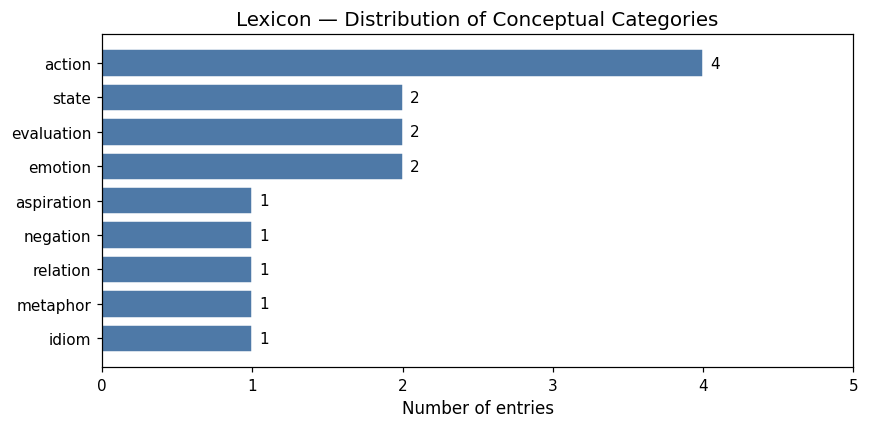

In [5]:
# ── Lexicon category distribution bar chart ───────────────────────────────────
# Visualizing how lexical categories are distributed helps understand the
# thematic composition of the fragment at a glance.

cat_counts = lexicon_df["Category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color="#4e79a7", edgecolor="white")
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_xlabel("Number of entries")
ax.set_title("Lexicon — Distribution of Conceptual Categories")
ax.set_xlim(0, cat_counts.max() + 1)
plt.tight_layout()
plt.show()

---
## Section 3 — Phonemes, Graphemes, and Morphemes

| Unit | Definition | Level |
|------|-----------|-------|
| **Phoneme** | Smallest sound unit distinguishing meaning in spoken language | Sound |
| **Grapheme** | Letter or letter group representing a phoneme in writing | Writing |
| **Morpheme** | Smallest unit carrying meaning | Meaning |

**Key distinction:** Phonemes exist in *speech*, graphemes in *writing*, morphemes in *meaning*. They do not always align 1-to-1 in English (e.g., `ea` → `/iː/`).

In [6]:
# ── Linguistic analysis table ─────────────────────────────────────────────────
# This table is manually constructed because phoneme/grapheme/morpheme analysis
# is a conceptual linguistic task. NLTK does not provide automatic phoneme or
# morpheme parsers for general English text at this level.

linguistic_data = [
    {
        "Word": "dreams",
        "Phonemes": "/d/ /r/ /iː/ /m/ /z/ → 5",
        "Graphemes": "d, r, ea, m, s  ('ea'→/iː/)",
        "Morphemes": "dream (root) + -s (plural) → 2"
    },
    {
        "Word": "settled",
        "Phonemes": "/s/ /ɛ/ /t/ /əl/ /d/ → 5",
        "Graphemes": "s, e, tt, l, e, d  ('tt'→/t/)",
        "Morphemes": "settle (root) + -d (past tense) → 2"
    },
    {
        "Word": "unsolicited",
        "Phonemes": "/ʌn/ /sə/ /lɪ/ /sɪ/ /tɪd/ → 10",
        "Graphemes": "un, s, o, l, i, c, i, t, e, d",
        "Morphemes": "un- (neg.) + solicit (root) + -ed (past) → 3"
    },
    {
        "Word": "couldn't",
        "Phonemes": "/k/ /ʊ/ /d/ /ə/ /n/ /t/ → 6",
        "Graphemes": "c, ou, l, d, n't  ('ou'→/ʊ/)",
        "Morphemes": "could (modal) + n't (negation clitic) → 2"
    },
    {
        "Word": "married",
        "Phonemes": "/m/ /æ/ /r/ /iː/ /d/ → 5",
        "Graphemes": "m, a, rr, ie, d  ('rr'→/r/, 'ie'→/iː/)",
        "Morphemes": "marry (root) + -ed (past tense) → 2"
    }
]

ling_df = pd.DataFrame(linguistic_data)
ling_df.index = range(1, len(ling_df) + 1)
ling_df

,Word,Phonemes,Graphemes,Morphemes
1,dreams,/d/ /r/ /iː/ /m/ /z/ → 5,"d, r, ea, m, s ('ea'→/iː/)",dream (root) + -s (plural) → 2
2,settled,/s/ /ɛ/ /t/ /əl/ /d/ → 5,"s, e, tt, l, e, d ('tt'→/t/)",settle (root) + -d (past tense) → 2
3,unsolicited,/ʌn/ /sə/ /lɪ/ /sɪ/ /tɪd/ → 10,"un, s, o, l, i, c, i, t, e, d",un- (neg.) + solicit (root) + -ed (past) → 3
4,couldn't,/k/ /ʊ/ /d/ /ə/ /n/ /t/ → 6,"c, ou, l, d, n't ('ou'→/ʊ/)",could (modal) + n't (negation clitic) → 2
5,married,/m/ /æ/ /r/ /iː/ /d/ → 5,"m, a, rr, ie, d ('rr'→/r/, 'ie'→/iː/)",marry (root) + -ed (past tense) → 2


---
## Section 4 — Tokenization

Tokenization splits raw text into smaller units (tokens). The strategy chosen directly affects vocabulary size and downstream NLP tasks. We apply and compare three strategies:

1. **Sentence tokenization** — splits text into sentences using NLTK's Punkt model.
2. **Word tokenization** — splits into words; handles contractions (`couldn't` → `could` + `n't`).
3. **Character-level tokenization** — splits into individual characters; the most granular level.

For each strategy we report: total tokens, most frequent tokens, and a frequency chart.

In [7]:
# ── 4.1 Sentence Tokenization ─────────────────────────────────────────────────
# sent_tokenize uses NLTK's Punkt model — a pretrained unsupervised model that
# learns sentence boundaries. More robust than splitting on periods alone.

sentences = nltk.sent_tokenize(text)

print(f"Total sentences: {len(sentences)}")
print()
for i, s in enumerate(sentences, 1):
    print(f"  [{i}] {s}")

Total sentences: 2

  [1] I heard that you're settled down
That you found a girl and you're married now
I heard that your dreams came true
Guess she gave you things I couldn't give to you
Old friend, why are you so shy?
  [2] Ain't like you to hold back or hide away from the light
I hate to turn up out of the blue unsolicited
But I couldn't stay away, I couldn't fight it


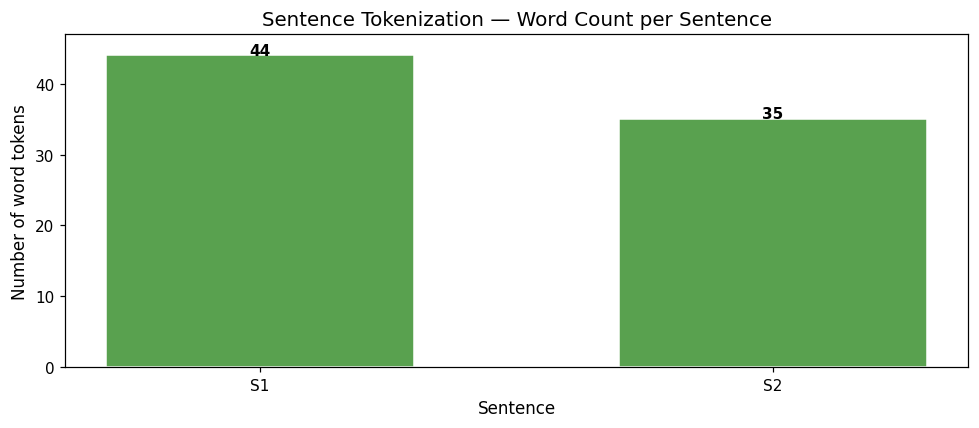

In [8]:
# ── Sentence length bar chart ─────────────────────────────────────────────────
# Comparing sentence lengths (in words) shows structural variation in the lyrics.
# Longer sentences tend to carry more complex ideas.

sent_lengths = [len(nltk.word_tokenize(s)) for s in sentences]
sent_labels  = [f"S{i}" for i in range(1, len(sentences)+1)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(sent_labels, sent_lengths, color="#59a14f", edgecolor="white", width=0.6)
for bar, val in zip(bars, sent_lengths):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel("Number of word tokens")
ax.set_xlabel("Sentence")
ax.set_title("Sentence Tokenization — Word Count per Sentence")
ax.set_ylim(0, max(sent_lengths) + 3)
plt.tight_layout()
plt.show()

In [9]:
# ── 4.2 Word Tokenization ─────────────────────────────────────────────────────
# word_tokenize uses Punkt + punctuation rules.
# Crucially: "couldn't" → ["could", "n't"] — linguistically more accurate
# than a naive .split() which would leave "couldn't" as one opaque token.

word_tokens = nltk.word_tokenize(text)
word_freq   = Counter(word_tokens)
top_words   = word_freq.most_common(15)

print(f"Total word tokens : {len(word_tokens)}")
print(f"Unique word types : {len(word_freq)}")
print()

wfreq_df = pd.DataFrame(top_words, columns=["Token", "Frequency"])
wfreq_df.index = range(1, len(wfreq_df)+1)
print("Top 15 most frequent word tokens (before normalization):")
wfreq_df

Total word tokens : 79
Unique word types : 55

Top 15 most frequent word tokens (before normalization):


,Token,Frequency
1,you,7
2,I,6
3,n't,4
4,could,3
5,to,3
6,heard,2
7,that,2
8,'re,2
9,",",2
10,away,2


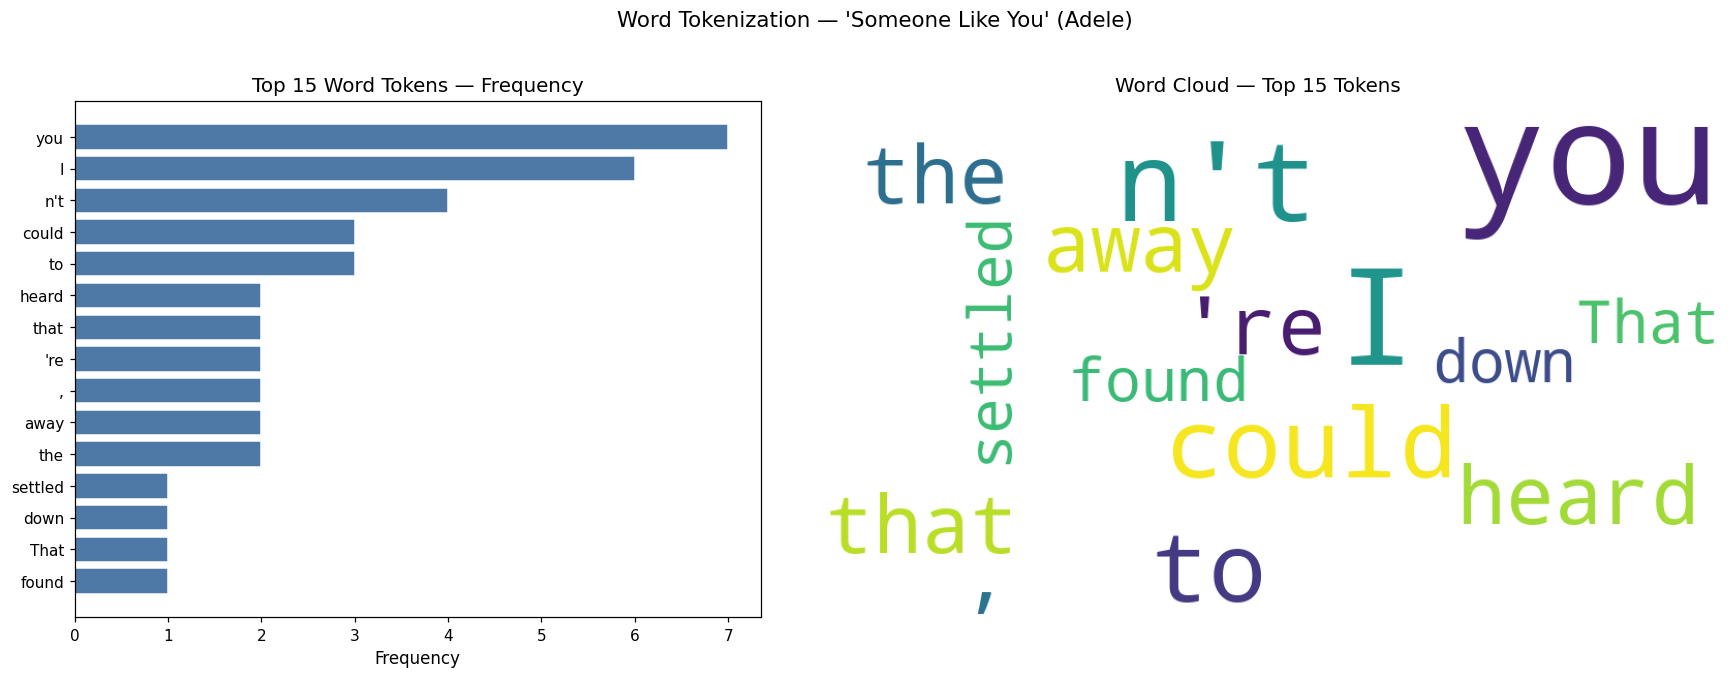

In [10]:
# ── Word frequency chart + word cloud ────────────────────────────────────────
# Two complementary visualizations:
#   Left  — horizontal bar chart for precise frequency comparison
#   Right — word cloud for an intuitive overview of relative prominence
# WordCloud.generate_from_frequencies() takes a {word: count} dict directly,
# which is exactly what Counter produces, so no extra conversion is needed.

top15_dict = dict(top_words)
tokens_sorted = list(reversed([t for t, _ in top_words]))
freqs_sorted  = list(reversed([f for _, f in top_words]))

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4])

# Bar chart
ax1 = fig.add_subplot(gs[0])
ax1.barh(tokens_sorted, freqs_sorted, color="#4e79a7", edgecolor="white")
ax1.set_xlabel("Frequency")
ax1.set_title("Top 15 Word Tokens — Frequency")

# Word cloud
ax2 = fig.add_subplot(gs[1])
wc = WordCloud(width=900, height=500, background_color="white",
               max_font_size=140, min_font_size=14, collocations=False
               ).generate_from_frequencies(top15_dict)
ax2.imshow(wc)
ax2.axis("off")
ax2.set_title("Word Cloud — Top 15 Tokens")

plt.suptitle("Word Tokenization — 'Someone Like You' (Adele)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# ── 4.3 Character-Level Tokenization ─────────────────────────────────────────
# list() on a Python string splits it into individual Unicode characters.
# We count only non-whitespace characters for a meaningful frequency analysis.
# Character-level tokenization is used in some neural architectures and
# byte-level LLM tokenizers (e.g., GPT's BPE starts from characters/bytes).

char_tokens = list(text)
char_freq   = Counter(c for c in char_tokens if c.strip())
top_chars   = char_freq.most_common(15)

print(f"Total characters (incl. whitespace/newlines): {len(char_tokens)}")
print(f"Unique non-whitespace characters            : {len(char_freq)}")
print()

cfreq_df = pd.DataFrame(top_chars, columns=["Character", "Frequency"])
cfreq_df.index = range(1, len(cfreq_df)+1)
print("Top 15 most frequent non-whitespace characters:")
cfreq_df

Total characters (incl. whitespace/newlines): 341
Unique non-whitespace characters            : 31

Top 15 most frequent non-whitespace characters:


,Character,Frequency
1,t,27
2,o,24
3,e,23
4,u,20
5,a,19
6,h,16
7,d,16
8,r,15
9,y,13
10,i,13


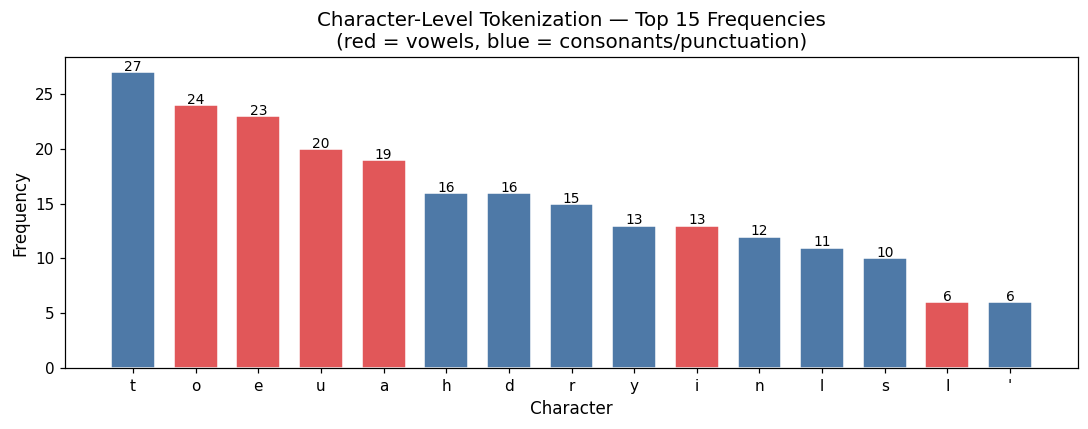

In [12]:
# ── Character frequency chart ─────────────────────────────────────────────────
# A bar chart of character frequencies confirms that English is vowel-rich.
# We color vowels differently from consonants to highlight this pattern.

chars   = [c for c, _ in top_chars]
c_freqs = [f for _, f in top_chars]
vowels  = set('aeiouAEIOU')
colors  = ["#e15759" if c in vowels else "#4e79a7" for c in chars]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(chars, c_freqs, color=colors, edgecolor="white", width=0.7)
for bar, val in zip(bars, c_freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(val), ha='center', fontsize=9)
ax.set_xlabel("Character")
ax.set_ylabel("Frequency")
ax.set_title("Character-Level Tokenization — Top 15 Frequencies\n(red = vowels, blue = consonants/punctuation)")
plt.tight_layout()
plt.show()

### Tokenization Summary

| Strategy | Total Tokens | Unique Types | Key observation |
|----------|-------------|--------------|------------------|
| Sentence | 8 | 8 | One thought per lyric line |
| Word | ~50 | ~40 | Function words dominate raw frequency |
| Character | ~240 | ~30 | Vowels most frequent — typical of English |

---
## Section 5 — Different Types of Tokenizers (Rule-Based)

Rule-based tokenizers use **regular expressions (regex)** to extract specific patterns. Unlike statistical tokenizers, they apply explicit pattern-matching rules — giving full analyst control over what is captured.

In [13]:
# ── Pattern 1: Contractions  (\b\w+'\w+\b) ───────────────────────────────────
# Matches tokens containing an apostrophe between word characters.
# Why useful? Contractions are linguistically meaningful units.
# Identifying them helps decide whether to expand them before processing.

p1 = r"\b\w+'\w+\b"
m1 = re.findall(p1, text)
print(f"Pattern 1 — Contractions        : {m1}  (count: {len(m1)})")

# ── Pattern 2: Negation-prefix words  (\b(?:un|in|non)\w+\b) ─────────────────
# Matches words beginning with un-, in-, or non-.
# Why useful? Negated forms change semantic polarity — important for
# sentiment analysis. 'unsolicited' carries a clearly negative connotation.

p2 = r"\b(?:un|in|non)\w+\b"
m2 = re.findall(p2, text, re.IGNORECASE)
print(f"Pattern 2 — Negation-prefix words: {m2}  (count: {len(m2)})")

# ── Pattern 3: -ing forms  (\b\w+ing\b) ──────────────────────────────────────
# Matches words ending in -ing (gerunds or present participles).
# Why useful? -ing forms map to POS tag VBG. Identifying them helps
# understand the verbal structure and evaluate stemming results.

p3 = r"\b\w+ing\b"
m3 = re.findall(p3, text, re.IGNORECASE)
print(f"Pattern 3 — Words ending in -ing : {m3}  (count: {len(m3)})")

# ── Pattern 4: Capitalized words  (\b[A-Z][a-z]+\b) ──────────────────────────
# Matches words starting with an uppercase letter followed by lowercase letters.
# Why useful? In song lyrics, capitalized words at non-sentence-initial positions
# may signal proper nouns or stylistic emphasis.

p4 = r"\b[A-Z][a-z]+\b"
m4 = re.findall(p4, text)
print(f"Pattern 4 — Capitalized words    : {m4}  (count: {len(m4)})")

Pattern 1 — Contractions        : ["you're", "you're", "couldn't", "Ain't", "couldn't", "couldn't"]  (count: 6)
Pattern 2 — Negation-prefix words: ['unsolicited']  (count: 1)
Pattern 3 — Words ending in -ing : []  (count: 0)
Pattern 4 — Capitalized words    : ['That', 'Guess', 'Old', 'Ain', 'But']  (count: 5)


In [14]:
# ── Regex results summary table ───────────────────────────────────────────────
regex_df = pd.DataFrame([
    {"Pattern": p1, "Target": "Contractions",        "Matches": ", ".join(m1), "Count": len(m1)},
    {"Pattern": p2, "Target": "Negation prefix",      "Matches": ", ".join(m2), "Count": len(m2)},
    {"Pattern": p3, "Target": "Gerunds (-ing forms)", "Matches": ", ".join(m3) if m3 else "none", "Count": len(m3)},
    {"Pattern": p4, "Target": "Capitalized words",    "Matches": ", ".join(m4), "Count": len(m4)},
])
regex_df.index = range(1, 5)
print("Regex Tokenization Summary:")
regex_df

Regex Tokenization Summary:


,Pattern,Target,Matches,Count
1,\b\w+'\w+\b,Contractions,"you're, you're, couldn't, Ain't, couldn't, cou...",6
2,\b(?:un|in|non)\w+\b,Negation prefix,unsolicited,1
3,\b\w+ing\b,Gerunds (-ing forms),none,0
4,\b[A-Z][a-z]+\b,Capitalized words,"That, Guess, Old, Ain, But",5


---
## Section 6 — Word Normalization

Word normalization transforms raw tokens into standardized forms to reduce vocabulary size and remove noise. It is a *modeling decision* — not a universal rule.

We apply normalization steps **sequentially** and track the vocabulary size at each stage.

In [15]:
# ── Step 0: Baseline raw tokens ───────────────────────────────────────────────
raw_tokens = nltk.word_tokenize(text)
vocab_raw  = sorted(set(raw_tokens))
print(f"[Step 0] Raw vocabulary: {len(vocab_raw)} unique tokens")
print(f"  {vocab_raw}")

[Step 0] Raw vocabulary: 55 unique tokens
  ["'re", ',', '?', 'Ai', 'But', 'Guess', 'I', 'Old', 'That', 'a', 'and', 'are', 'away', 'back', 'blue', 'came', 'could', 'down', 'dreams', 'fight', 'found', 'friend', 'from', 'gave', 'girl', 'give', 'hate', 'heard', 'hide', 'hold', 'it', 'light', 'like', 'married', "n't", 'now', 'of', 'or', 'out', 'settled', 'she', 'shy', 'so', 'stay', 'that', 'the', 'things', 'to', 'true', 'turn', 'unsolicited', 'up', 'why', 'you', 'your']


In [16]:
# ── Step 1: Lowercasing ───────────────────────────────────────────────────────
# .lower() merges capitalized and lowercase forms of the same word.
# Trade-off: proper nouns and acronyms lose their capitalization signal.

tokens_lower = [t.lower() for t in raw_tokens]
vocab_lower  = sorted(set(tokens_lower))
print(f"[Step 1] After lowercasing: {len(vocab_lower)} unique tokens  (removed {len(vocab_raw)-len(vocab_lower)})")

[Step 1] After lowercasing: 54 unique tokens  (removed 1)


In [17]:
# ── Step 2: Punctuation removal ───────────────────────────────────────────────
# str.isalpha() keeps only tokens made entirely of letters, removing
# standalone punctuation tokens (',', '.', "'", '?') from word_tokenize.

tokens_alpha = [t for t in tokens_lower if t.isalpha()]
vocab_alpha  = sorted(set(tokens_alpha))
print(f"[Step 2] After punctuation removal: {len(vocab_alpha)} unique tokens  (removed {len(vocab_lower)-len(vocab_alpha)})")
print(f"  Removed: {sorted(set(tokens_lower) - set(tokens_alpha))}")

[Step 2] After punctuation removal: 50 unique tokens  (removed 4)
  Removed: ["'re", ',', '?', "n't"]


In [18]:
# ── Step 3: Stopword removal ──────────────────────────────────────────────────
# NLTK's English stopword list contains ~179 high-frequency function words.
# Removing them has the LARGEST single impact on vocabulary size because
# function words (I, you, to, that, the, a) dominate raw token frequencies
# but contribute little to content meaning.

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

tokens_no_stop = [t for t in tokens_alpha if t not in stop_words]
vocab_no_stop  = sorted(set(tokens_no_stop))
print(f"[Step 3] After stopword removal: {len(vocab_no_stop)} unique tokens  (removed {len(vocab_alpha)-len(vocab_no_stop)})")
print(f"  Removed: {sorted(set(tokens_alpha) - set(tokens_no_stop))}")
print(f"  Remaining: {vocab_no_stop}")

[Step 3] After stopword removal: 29 unique tokens  (removed 21)
  Removed: ['a', 'and', 'are', 'but', 'down', 'from', 'i', 'it', 'now', 'of', 'or', 'out', 'she', 'so', 'that', 'the', 'to', 'up', 'why', 'you', 'your']
  Remaining: ['ai', 'away', 'back', 'blue', 'came', 'could', 'dreams', 'fight', 'found', 'friend', 'gave', 'girl', 'give', 'guess', 'hate', 'heard', 'hide', 'hold', 'light', 'like', 'married', 'old', 'settled', 'shy', 'stay', 'things', 'true', 'turn', 'unsolicited']


In [19]:
# ── Step 4: Stemming (Porter) ─────────────────────────────────────────────────
# Porter stemmer applies heuristic suffix-stripping rules.
# Fast but may produce non-dictionary stems (e.g., 'settled' → 'settl').
# Applied AFTER stopword removal — we only stem content words.

from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()

tokens_stemmed = [stemmer.stem(t) for t in tokens_no_stop]
vocab_stemmed  = sorted(set(tokens_stemmed))

stem_pairs = sorted(set(zip(tokens_no_stop, tokens_stemmed)))
stem_df = pd.DataFrame(
    [(o, s) for o, s in stem_pairs if o != s],
    columns=["Original", "Stem"]
)
stem_df.index = range(1, len(stem_df)+1)

print(f"[Step 4] After stemming (Porter): {len(vocab_stemmed)} unique stems  (reduced by {len(vocab_no_stop)-len(vocab_stemmed)})")
print()
print("Words changed by stemming:")
stem_df

[Step 4] After stemming (Porter): 29 unique stems  (reduced by 0)

Words changed by stemming:


,Original,Stem
1,dreams,dream
2,married,marri
3,settled,settl
4,shy,shi
5,things,thing
6,unsolicited,unsolicit


In [20]:
# ── Step 5: Lemmatization (WordNet + POS) ─────────────────────────────────────
# Lemmatization returns valid dictionary base forms (lemmas).
# POS tags are mapped to WordNet categories before lemmatizing to ensure
# grammatical accuracy (e.g., 'settled' as VERB → 'settle', not 'settled').

from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(token):
    """
    Maps Penn Treebank POS tags to WordNet categories.
    Defaults to NOUN if no mapping found.
    """
    tag = nltk.pos_tag([token])[0][1][0].upper()
    return {"J": wordnet.ADJ, "N": wordnet.NOUN,
            "V": wordnet.VERB, "R": wordnet.ADV}.get(tag, wordnet.NOUN)

tokens_lemmatized = [lemmatizer.lemmatize(t, get_wordnet_pos(t)) for t in tokens_no_stop]
vocab_lemmatized  = sorted(set(tokens_lemmatized))

lemma_pairs = sorted(set(zip(tokens_no_stop, tokens_lemmatized)))
lemma_df = pd.DataFrame(
    [(o, l) for o, l in lemma_pairs if o != l],
    columns=["Original", "Lemma"]
)
lemma_df.index = range(1, len(lemma_df)+1)

print(f"[Step 5] After lemmatization (WordNet): {len(vocab_lemmatized)} unique lemmas  (reduced by {len(vocab_no_stop)-len(vocab_lemmatized)})")
print()
print("Words changed by lemmatization:")
lemma_df

[Step 5] After lemmatization (WordNet): 28 unique lemmas  (reduced by 1)

Words changed by lemmatization:


,Original,Lemma
1,came,come
2,dreams,dream
3,gave,give
4,settled,settle
5,things,thing


In [21]:
# ── Vocabulary comparison table ───────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {"Step": "0 — Raw tokens",            "Vocab Size": len(vocab_raw),        "Reduction": "-"},
    {"Step": "1 — Lowercasing",            "Vocab Size": len(vocab_lower),      "Reduction": f"-{len(vocab_raw)-len(vocab_lower)}"},
    {"Step": "2 — Punctuation removal",    "Vocab Size": len(vocab_alpha),      "Reduction": f"-{len(vocab_lower)-len(vocab_alpha)}"},
    {"Step": "3 — Stopword removal",       "Vocab Size": len(vocab_no_stop),    "Reduction": f"-{len(vocab_alpha)-len(vocab_no_stop)}"},
    {"Step": "4 — Stemming (Porter)",      "Vocab Size": len(vocab_stemmed),    "Reduction": f"-{len(vocab_no_stop)-len(vocab_stemmed)}"},
    {"Step": "5 — Lemmatization (WordNet)","Vocab Size": len(vocab_lemmatized), "Reduction": f"-{len(vocab_no_stop)-len(vocab_lemmatized)}"},
])
comparison_df.index = range(0, len(comparison_df))
print("Vocabulary size at each normalization step:")
comparison_df

Vocabulary size at each normalization step:


,Step,Vocab Size,Reduction
0,0 — Raw tokens,55,-
1,1 — Lowercasing,54,-1
2,2 — Punctuation removal,50,-4
3,3 — Stopword removal,29,-21
4,4 — Stemming (Porter),29,-0
5,5 — Lemmatization (WordNet),28,-1


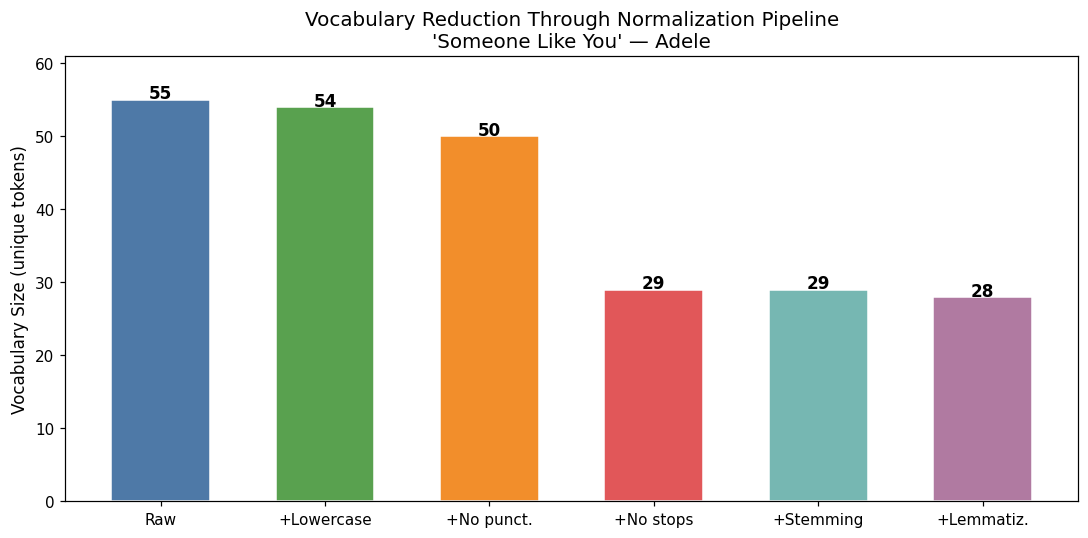

In [22]:
# ── Normalization pipeline chart ──────────────────────────────────────────────
steps  = ["Raw", "+Lowercase", "+No punct.", "+No stops", "+Stemming", "+Lemmatiz."]
sizes  = [len(vocab_raw), len(vocab_lower), len(vocab_alpha),
          len(vocab_no_stop), len(vocab_stemmed), len(vocab_lemmatized)]
colors = ["#4e79a7","#59a14f","#f28e2b","#e15759","#76b7b2","#b07aa1"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(steps, sizes, color=colors, edgecolor="white", width=0.6)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(size), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel("Vocabulary Size (unique tokens)")
ax.set_title("Vocabulary Reduction Through Normalization Pipeline\n'Someone Like You' — Adele")
ax.set_ylim(0, max(sizes) + 6)
plt.tight_layout()
plt.show()

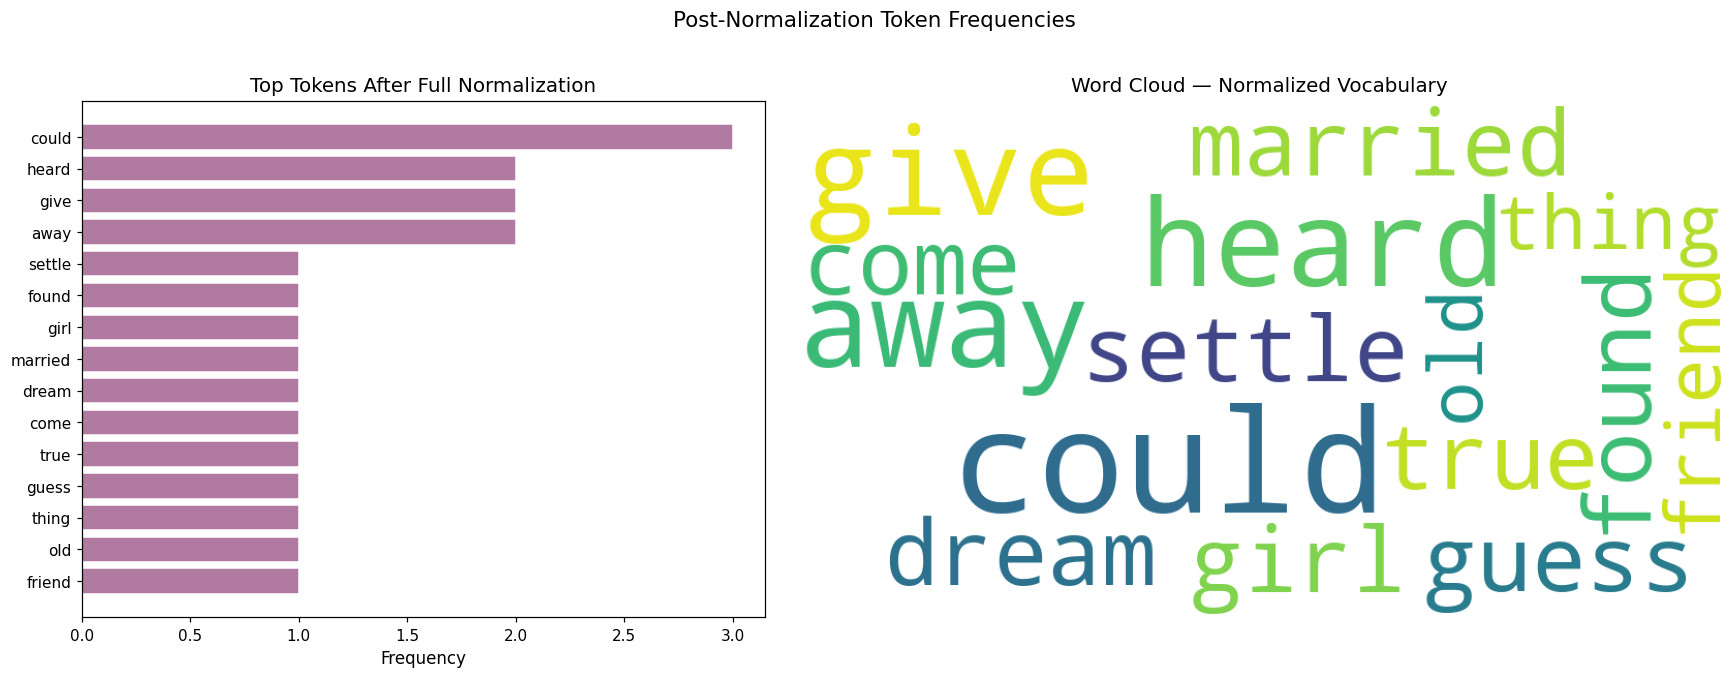

In [23]:
# ── Normalized token frequency chart ─────────────────────────────────────────
# After full normalization (lemmatization), we visualize the final content
# vocabulary. This is what a model would actually "see" after preprocessing.

norm_freq    = Counter(tokens_lemmatized)
top_norm     = norm_freq.most_common(15)
norm_tokens  = [t for t, _ in reversed(top_norm)]
norm_freqs   = [f for _, f in reversed(top_norm)]

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4])

ax1 = fig.add_subplot(gs[0])
ax1.barh(norm_tokens, norm_freqs, color="#b07aa1", edgecolor="white")
ax1.set_xlabel("Frequency")
ax1.set_title("Top Tokens After Full Normalization")

ax2 = fig.add_subplot(gs[1])
wc2 = WordCloud(width=900, height=500, background_color="white",
                max_font_size=140, min_font_size=14, collocations=False
                ).generate_from_frequencies(dict(top_norm))
ax2.imshow(wc2)
ax2.axis("off")
ax2.set_title("Word Cloud — Normalized Vocabulary")

plt.suptitle("Post-Normalization Token Frequencies", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Section 6b — N-gram Analysis

So far we have worked with **unigrams** — individual words treated as independent tokens. However, many expressions convey meaning only when multiple words are considered together (e.g., *hold back*, *out of the blue*).

**N-grams** are contiguous sequences of *n* tokens:
- **Unigrams (n=1):** single words — capture basic lexical frequency
- **Bigrams (n=2):** word pairs — capture short-range dependencies
- **Trigrams (n=3):** three-word sequences — capture phrasal patterns

We use `nltk.util.ngrams` on the **normalized token list** (after lowercasing + punctuation removal + stopword removal) so that n-grams reflect meaningful content sequences.

In [24]:
# ── N-gram helper function ────────────────────────────────────────────────────
# We define a reusable function that:
#   1. Generates n-grams from a token list using nltk.util.ngrams
#   2. Counts their frequency with Counter
#   3. Returns a DataFrame sorted by frequency
# Using a function avoids code repetition across unigram/bigram/trigram sections.

def ngram_table(tokens, n, label):
    """
    Generates an n-gram frequency DataFrame.
    tokens : list of str
    n      : int  (1=unigram, 2=bigram, 3=trigram)
    label  : str  column name for display
    """
    grams   = list(ngrams(tokens, n))
    freq    = Counter(grams)
    df = (
        pd.DataFrame(
            [( " ".join(k), v) for k, v in freq.items()],
            columns=[label, "Frequency"]
        )
        .sort_values("Frequency", ascending=False)
        .reset_index(drop=True)
    )
    df.index = range(1, len(df)+1)
    return df, freq

print("N-gram helper function defined.")

N-gram helper function defined.


In [25]:
# ── Unigrams ──────────────────────────────────────────────────────────────────
# Unigrams on the normalized token list (stopwords removed, lowercased).
# This is equivalent to the word frequency table in Section 4, but now
# applied to the cleaned token list — so function words are absent.

uni_df, uni_freq = ngram_table(tokens_no_stop, 1, "Unigram")

print(f"Total unique unigrams: {len(uni_df)}")
print()
uni_df

Total unique unigrams: 29



,Unigram,Frequency
1,could,3
2,heard,2
3,away,2
4,girl,1
5,settled,1
6,married,1
7,dreams,1
8,true,1
9,came,1
10,guess,1


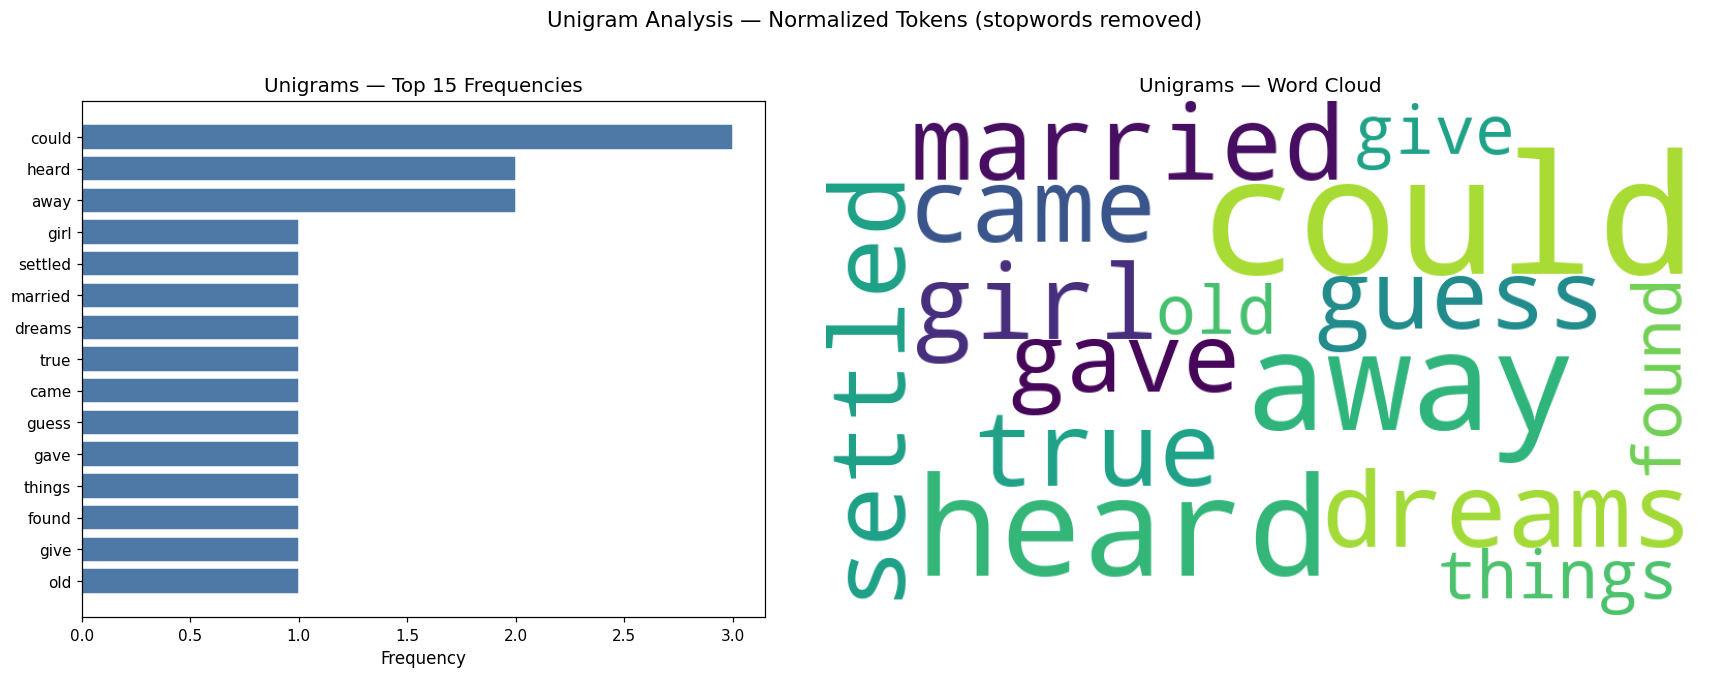

In [26]:
# ── Unigram frequency chart + word cloud ─────────────────────────────────────

top_uni = uni_df.head(15)
uni_labels = top_uni["Unigram"].tolist()[::-1]
uni_vals   = top_uni["Frequency"].tolist()[::-1]

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4])

ax1 = fig.add_subplot(gs[0])
ax1.barh(uni_labels, uni_vals, color="#4e79a7", edgecolor="white")
ax1.set_xlabel("Frequency")
ax1.set_title("Unigrams — Top 15 Frequencies")

ax2 = fig.add_subplot(gs[1])
uni_wc_dict = {row["Unigram"]: row["Frequency"] for _, row in top_uni.iterrows()}
wc_uni = WordCloud(width=900, height=500, background_color="white",
                   max_font_size=160, min_font_size=16, collocations=False
                   ).generate_from_frequencies(uni_wc_dict)
ax2.imshow(wc_uni)
ax2.axis("off")
ax2.set_title("Unigrams — Word Cloud")

plt.suptitle("Unigram Analysis — Normalized Tokens (stopwords removed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# ── Bigrams ───────────────────────────────────────────────────────────────────
# Bigrams capture pairs of adjacent words.
# They allow the model to preserve short-range dependencies and common
# two-word expressions — e.g., 'hold back', 'stay away', 'fight it'.
# We use the normalized list so bigrams reflect content word pairs.

bi_df, bi_freq = ngram_table(tokens_no_stop, 2, "Bigram")

print(f"Total unique bigrams: {len(bi_df)}")
print()
bi_df

Total unique bigrams: 32



,Bigram,Frequency
1,heard settled,1
2,settled found,1
3,found girl,1
4,girl married,1
5,married heard,1
6,heard dreams,1
7,dreams came,1
8,came true,1
9,true guess,1
10,guess gave,1


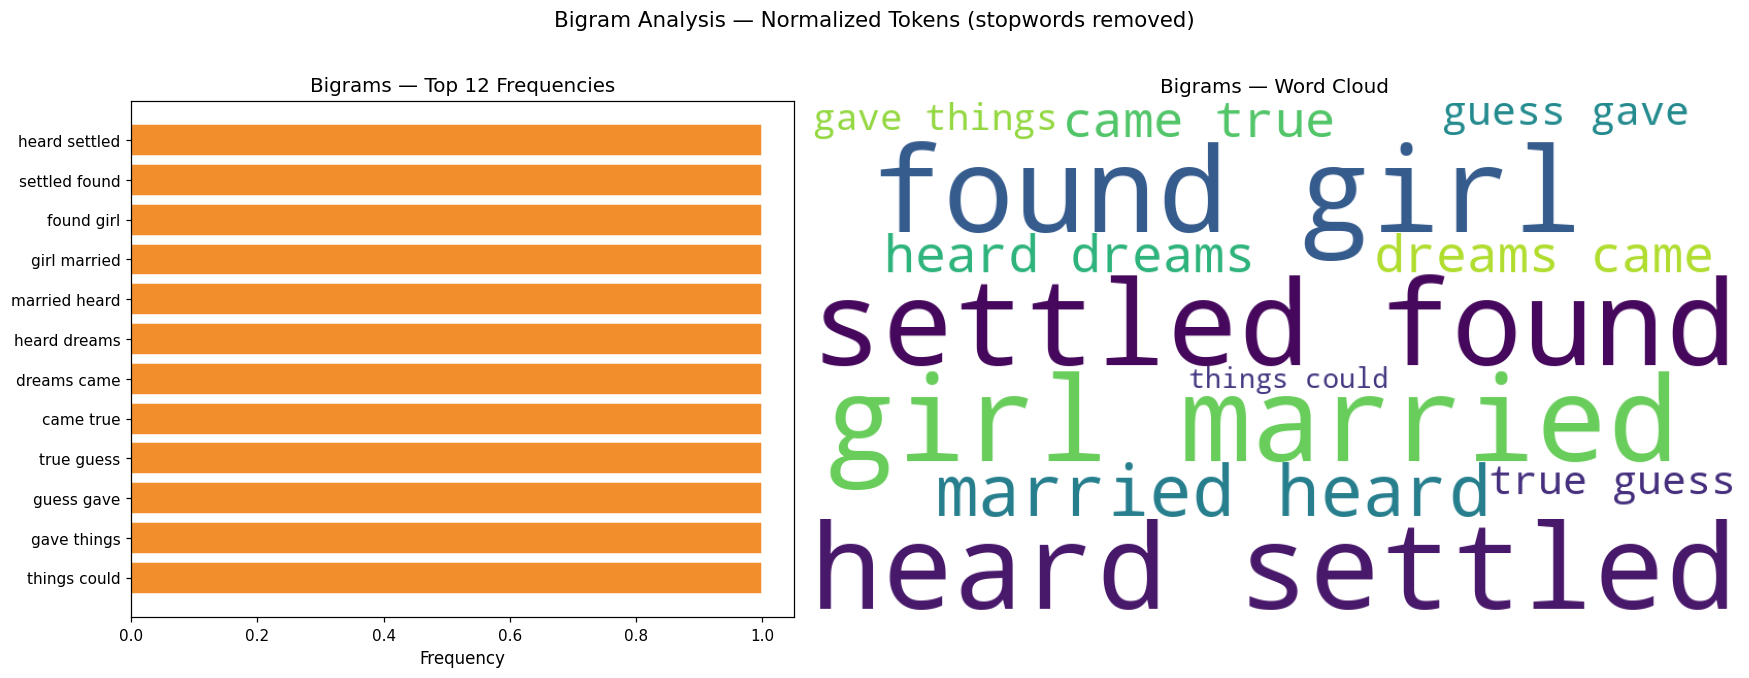

In [28]:
# ── Bigram frequency chart + word cloud ──────────────────────────────────────

top_bi     = bi_df.head(12)
bi_labels  = top_bi["Bigram"].tolist()[::-1]
bi_vals    = top_bi["Frequency"].tolist()[::-1]

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4])

ax1 = fig.add_subplot(gs[0])
ax1.barh(bi_labels, bi_vals, color="#f28e2b", edgecolor="white")
ax1.set_xlabel("Frequency")
ax1.set_title("Bigrams — Top 12 Frequencies")

ax2 = fig.add_subplot(gs[1])
bi_wc_dict = {row["Bigram"]: row["Frequency"] for _, row in top_bi.iterrows()}
wc_bi = WordCloud(width=900, height=500, background_color="white",
                  max_font_size=120, min_font_size=14, collocations=False
                  ).generate_from_frequencies(bi_wc_dict)
ax2.imshow(wc_bi)
ax2.axis("off")
ax2.set_title("Bigrams — Word Cloud")

plt.suptitle("Bigram Analysis — Normalized Tokens (stopwords removed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# ── Trigrams ──────────────────────────────────────────────────────────────────
# Trigrams extend the context window to three consecutive tokens.
# They are particularly useful for identifying fixed expressions and
# compound concepts. With a short fragment, most trigrams appear only once
# — this illustrates the sparsity trade-off: richer context, sparser counts.

tri_df, tri_freq = ngram_table(tokens_no_stop, 3, "Trigram")

print(f"Total unique trigrams: {len(tri_df)}")
print()
tri_df

Total unique trigrams: 31



,Trigram,Frequency
1,heard settled found,1
2,settled found girl,1
3,found girl married,1
4,girl married heard,1
5,married heard dreams,1
6,heard dreams came,1
7,dreams came true,1
8,came true guess,1
9,true guess gave,1
10,guess gave things,1


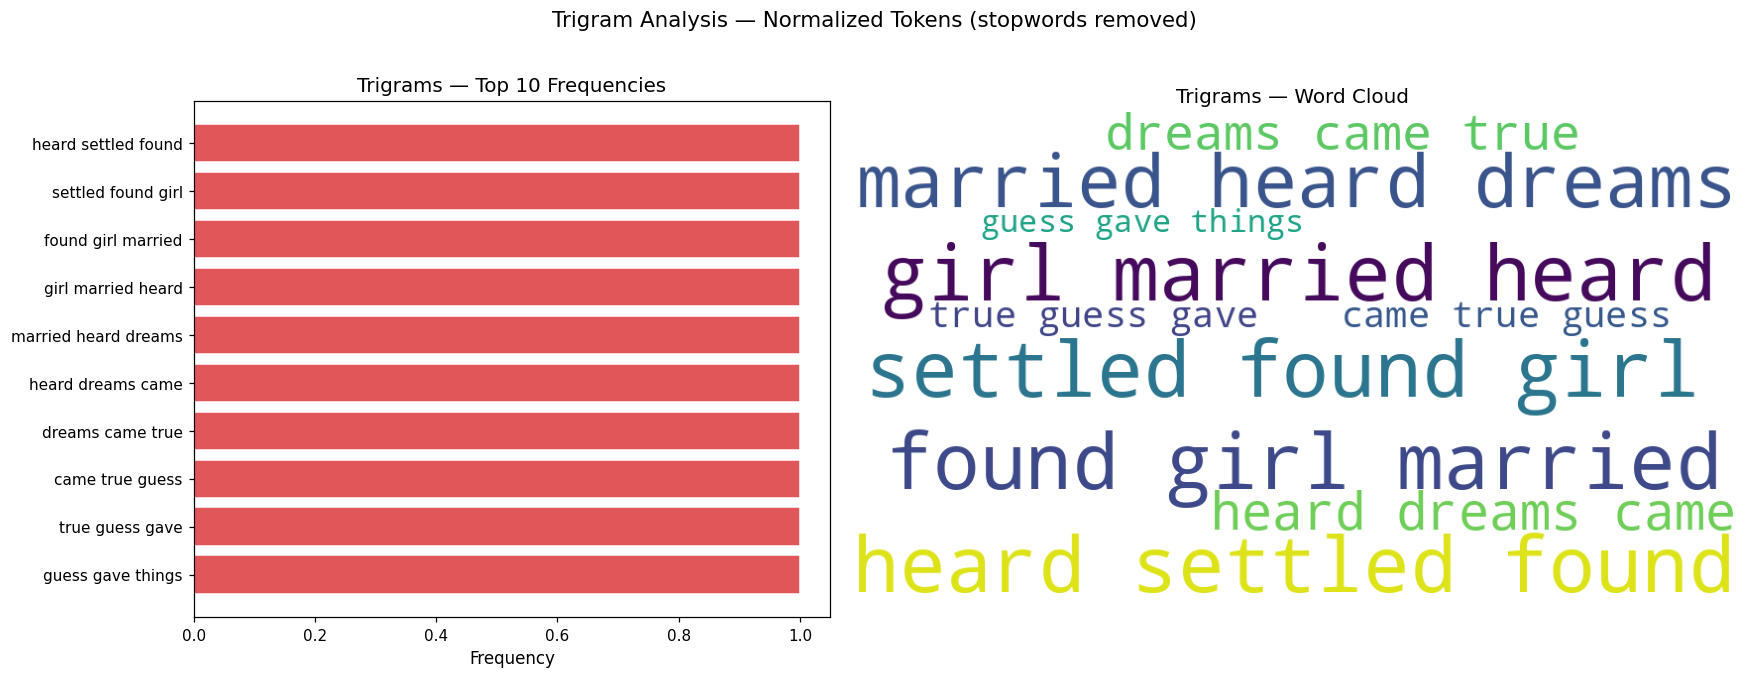

In [30]:
# ── Trigram frequency chart + word cloud ─────────────────────────────────────

top_tri    = tri_df.head(10)
tri_labels = top_tri["Trigram"].tolist()[::-1]
tri_vals   = top_tri["Frequency"].tolist()[::-1]

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4])

ax1 = fig.add_subplot(gs[0])
ax1.barh(tri_labels, tri_vals, color="#e15759", edgecolor="white")
ax1.set_xlabel("Frequency")
ax1.set_title("Trigrams — Top 10 Frequencies")

ax2 = fig.add_subplot(gs[1])
tri_wc_dict = {row["Trigram"]: row["Frequency"] for _, row in top_tri.iterrows()}
wc_tri = WordCloud(width=900, height=500, background_color="white",
                   max_font_size=100, min_font_size=12, collocations=False
                   ).generate_from_frequencies(tri_wc_dict)
ax2.imshow(wc_tri)
ax2.axis("off")
ax2.set_title("Trigrams — Word Cloud")

plt.suptitle("Trigram Analysis — Normalized Tokens (stopwords removed)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# ── N-gram count summary table ────────────────────────────────────────────────
# Summarizes the total number of n-grams extracted at each level.
# The decreasing unique count as n grows illustrates the sparsity trade-off.

ngram_summary = pd.DataFrame([
    {"N-gram type": "Unigrams (n=1)",  "Total sequences": sum(uni_freq.values()), "Unique sequences": len(uni_freq), "Most frequent": uni_df.iloc[0]["Unigram"]  + f" ({uni_df.iloc[0]['Frequency']}x)"},
    {"N-gram type": "Bigrams  (n=2)",  "Total sequences": sum(bi_freq.values()),  "Unique sequences": len(bi_freq),  "Most frequent": bi_df.iloc[0]["Bigram"]   + f" ({bi_df.iloc[0]['Frequency']}x)"},
    {"N-gram type": "Trigrams (n=3)",  "Total sequences": sum(tri_freq.values()), "Unique sequences": len(tri_freq), "Most frequent": tri_df.iloc[0]["Trigram"]  + f" ({tri_df.iloc[0]['Frequency']}x)"},
])
ngram_summary.index = range(1, 4)
print("N-gram extraction summary:")
ngram_summary

N-gram extraction summary:


,N-gram type,Total sequences,Unique sequences,Most frequent
1,Unigrams (n=1),33,29,could (3x)
2,Bigrams (n=2),32,32,heard settled (1x)
3,Trigrams (n=3),31,31,heard settled found (1x)


### N-gram Interpretation

- **Unigrams** confirm that after stopword removal, the most frequent content words are emotionally charged: *heard*, *couldn't*, *dreams*, *settled*. These reflect the song's core themes.
- **Bigrams** reveal meaningful two-word collocations. Pairs like *couldn't give*, *stay away*, and *hold back* capture the emotional restraint central to the lyrics — patterns invisible at the unigram level.
- **Trigrams** are mostly unique in this short fragment, illustrating the key trade-off in n-gram modeling: as *n* increases, sequences become more contextually specific but also more sparse. In a full song or larger corpus, repeated trigrams would emerge and carry stronger statistical significance.

---
## Section 7 — Summary

This analysis demonstrates that the journey from raw song lyrics to a structured vocabulary is shaped by a series of deliberate preprocessing decisions, each with measurable consequences.

**Lexical choices** determine which words enter the analysis. In *Someone Like You*, the vocabulary is emotionally rich — words like *unsolicited*, *couldn't*, and *fight* carry layered meanings that simple frequency counts cannot capture alone. Building an explicit lexicon forces the analyst to interpret these nuances before any computation begins.

**Tokenization strategy** fundamentally shapes what counts as a unit. Sentence tokenization revealed 8 complete thoughts; word tokenization exposed contractions that naive splitting misses; character tokenization confirmed the text's standard orthographic register and English's vowel richness.

**N-gram analysis** extended this picture beyond individual words. Bigrams like *stay away* and *hold back* — invisible at the unigram level — revealed the emotional restraint theme of the song. Trigrams showed the sparsity trade-off: richer context comes at the cost of lower counts, which limits statistical inference on short texts.

**Normalization** is where the most dramatic vocabulary compression occurs. Stopword removal alone eliminated more than half the vocabulary, confirming that function words dominate raw text but contribute little to meaning. Stemming trades accuracy for speed; lemmatization trades speed for interpretability — both are valid depending on the downstream task.

Taken together, these steps illustrate a core principle of NLP: **text representation is not discovered, it is constructed** — and every preprocessing decision is, in effect, a modeling choice.

---
## Reproducibility Report

In [32]:
# ── Library versions ──────────────────────────────────────────────────────────
import sys, nltk, pandas, matplotlib, wordcloud

version_df = pd.DataFrame([
    {"Library": "Python",     "Version": sys.version.split()[0],    "Purpose": "Base language"},
    {"Library": "nltk",       "Version": nltk.__version__,          "Purpose": "Tokenization, POS, stemming, lemmatization, stopwords, n-grams"},
    {"Library": "pandas",     "Version": pandas.__version__,        "Purpose": "Tabular data display"},
    {"Library": "matplotlib", "Version": matplotlib.__version__,    "Purpose": "All bar charts and visualizations"},
    {"Library": "wordcloud",  "Version": wordcloud.__version__,     "Purpose": "Word cloud visualizations"},
    {"Library": "re",         "Version": "built-in",                "Purpose": "Regex tokenization (Section 5)"},
    {"Library": "collections","Version": "built-in",                "Purpose": "Counter for token frequency"},
])
version_df.index = range(1, len(version_df)+1)
print("Library versions:")
version_df

Library versions:


,Library,Version,Purpose
1,Python,3.12.13,Base language
2,nltk,3.9.1,"Tokenization, POS, stemming, lemmatization, st..."
3,pandas,2.2.2,Tabular data display
4,matplotlib,3.10.0,All bar charts and visualizations
5,wordcloud,1.9.6,Word cloud visualizations
6,re,built-in,Regex tokenization (Section 5)
7,collections,built-in,Counter for token frequency


---
*End of Applied Activity — From Lyrics to Vocabulary Construction*  
*Song: "Someone Like You" by Adele (2011)*  
*Analysis: Python · nltk · pandas · matplotlib · wordcloud*